In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import requests
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

shap.initjs()

c:\Users\User\credit-risk-pipeline\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load Data
df = pd.read_csv('../data/credit_risk_dataset.csv')

#Clean Outliers
df = df[df['person_age'] <= 90]
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df = df[df['person_emp_length'] <= df['person_age']]

In [3]:
#feature engineering : Creating logical features 
df['employment_status'] = np.where(df['person_emp_length'] > 0, 'EMPLOYED', 'UNEMPLOYED')
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

#Drop useless/leaky columns ---> Prevention from Data leakage
df = df.drop(['loan_grade', 'person_emp_length'], axis=1)

#making one-hgot encoding for categorical features
df_final = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'employment_status'], 
                          drop_first=False, 
                          dtype=int)

In [4]:
# 1. Isolate known vs missing
known_rates = df_final[df_final['loan_int_rate'].notnull()]
missing_rates = df_final[df_final['loan_int_rate'].isnull()]

# 2. Define the "Blindfold" (Hide the answer key)
allowed_features = known_rates.drop(['loan_status', 'loan_int_rate'], axis=1).columns

# 3. Train the Imputer
xgb_imputer = XGBRegressor(random_state=42)
xgb_imputer.fit(known_rates[allowed_features], known_rates['loan_int_rate'])

# 4. Predict and Inject
df_final.loc[
    df_final['loan_int_rate'].isnull(), 'loan_int_rate'
] = xgb_imputer.predict(missing_rates[allowed_features])

print(f"Missing rates filled: {missing_rates.shape[0]} rows")

Missing rates filled: 3114 rows


In [5]:
#Train and Test Split step / Applying XGboost Classifier
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Calculate Punishment Multiplier
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 3. Train the Model
xgb_model = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=50)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
# 1. Get raw percentages
y_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# 2. Find optimal threshold for F1
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probabilities)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

# 3. Make Final Decisions
optimized_predictions = (y_probabilities >= best_threshold).astype(int)
print(f"Optimal Threshold: {best_threshold:.3f}")
print(classification_report(y_test, optimized_predictions))

Optimal Threshold: 0.643
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5084
           1       0.88      0.74      0.80      1431

    accuracy                           0.92      6515
   macro avg       0.90      0.86      0.88      6515
weighted avg       0.92      0.92      0.92      6515



In [7]:
# Using SHAP to explain the model's predictions
explainer = shap.TreeExplainer(xgb_model)

# Shap value for entire X_test
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (6515, 19)


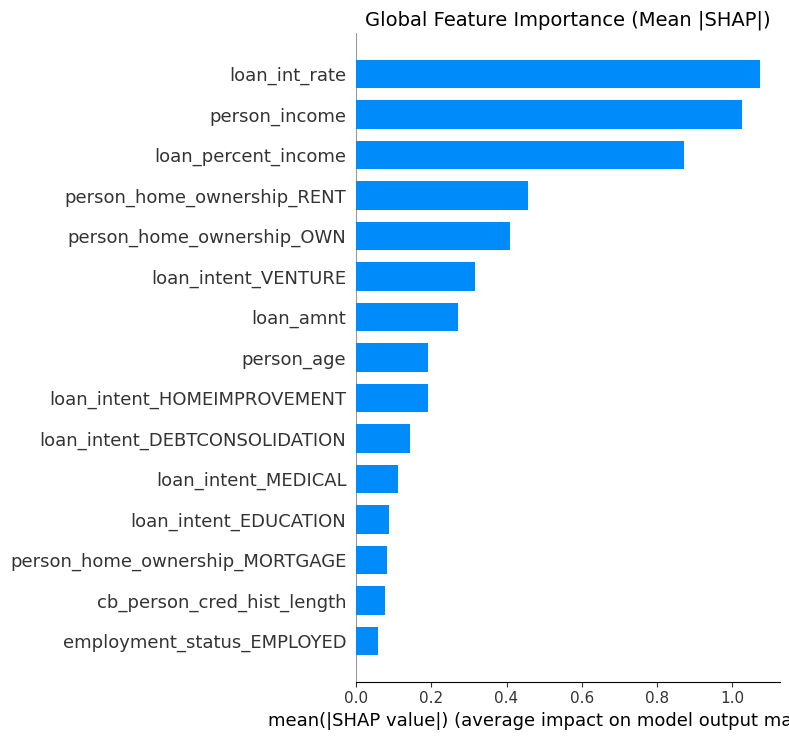

In [8]:
# SHAP PLOT 1 : Which features matter MOST on average across all applicants?
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',      
    max_display=15,       
    show=False
)
plt.title("Global Feature Importance (Mean |SHAP|)", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Step 1: See the raw default rate by prior default history
cross = pd.crosstab(
    df_final['cb_person_default_on_file'],
    df_final['loan_status']
)
print("Raw counts:")
print(cross)
print("\nDefault rate:")
print(cross.div(cross.sum(axis=1), axis=0).round(3))

# Step 2: See what SHAP value cb_person_default_on_file 
# actually gets (it might be present, just below top 15)
feature_names = list(X_test.columns)
shap_means = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\nFull SHAP ranking (all features):")
print(shap_means)

# Step 3: Find exactly where cb_person_default_on_file ranks
rank = shap_means.index.get_loc('cb_person_default_on_file') + 1
print(f"\ncb_person_default_on_file ranks #{rank} out of {len(feature_names)} features")
print(f"Its mean |SHAP| value: {shap_means['cb_person_default_on_file']:.4f}")

Raw counts:
loan_status                    0     1
cb_person_default_on_file             
0                          21893  4936
1                           3573  2171

Default rate:
loan_status                    0      1
cb_person_default_on_file              
0                          0.816  0.184
1                          0.622  0.378

Full SHAP ranking (all features):
loan_int_rate                     1.073338
person_income                     1.027284
loan_percent_income               0.872080
person_home_ownership_RENT        0.456726
person_home_ownership_OWN         0.408388
loan_intent_VENTURE               0.316494
loan_amnt                         0.271410
person_age                        0.192476
loan_intent_HOMEIMPROVEMENT       0.190288
loan_intent_DEBTCONSOLIDATION     0.143352
loan_intent_MEDICAL               0.111542
loan_intent_EDUCATION             0.087122
person_home_ownership_MORTGAGE    0.083028
cb_person_cred_hist_length        0.076062
employment_status_EM

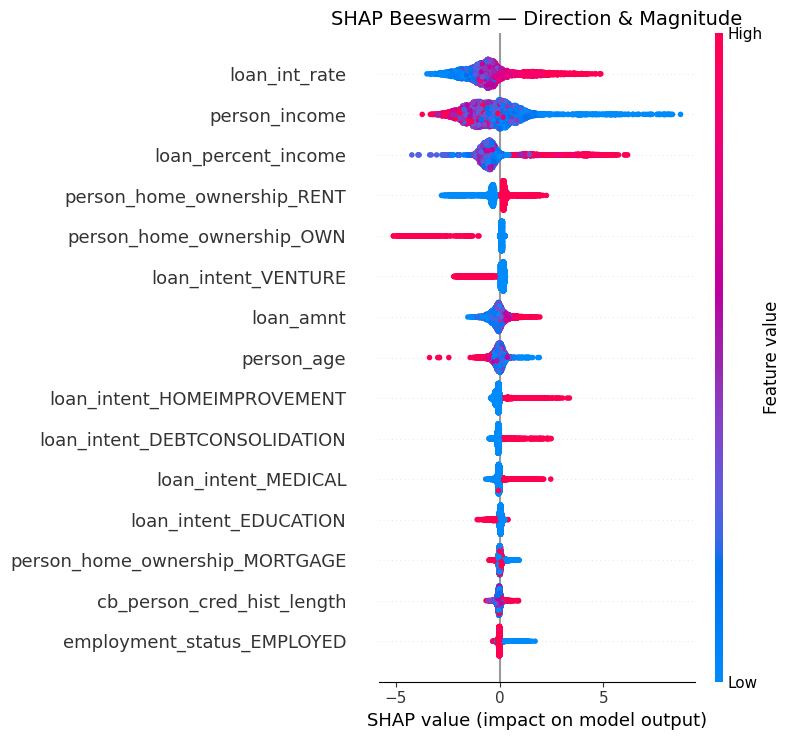

In [10]:
# bee swarm plot
# "HOW does each feature push the prediction — and in which direction?"
# Red = high feature value, Blue = low feature value
# Right side = pushes toward DEFAULT, Left = pushes toward SAFE

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',      # beeswarm / dot plot
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Direction & Magnitude", fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

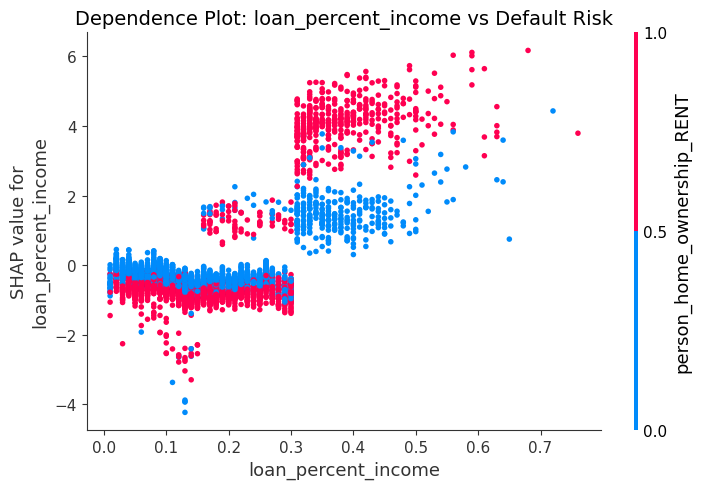

In [11]:
# Dependence Plot
# "How does loan_percent_income specifically affect default risk?"
plt.figure()
shap.dependence_plot(
    'loan_percent_income',
    shap_values,
    X_test,
    interaction_index='auto',  # auto-colours by the most correlated feature
    show=False
)
plt.title("Dependence Plot: loan_percent_income vs Default Risk", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
def format_inr(number):
    """Formats a number into Indian comma-separated currency style."""
    s, *d = str(int(number)).partition(".")
    r = ",".join([s[x-2:x] for x in range(-3, -len(s), -2)][::-1] + [s[-3:]])
    return "".join([r] + d)


def get_local_shap_explanation(model_input_row, explainer, feature_names, top_n=3):
    """
    Computes LOCAL SHAP for a single applicant.
    Returns:
        - A human-readable string listing the top risk drivers
        - A list of (feature, shap_value) tuples for the top N features
    """
    local_shap = explainer.shap_values(model_input_row)  # shape: (1, n_features)
    shap_series = pd.Series(local_shap[0], index=feature_names)

    # Positive SHAP = pushes toward DEFAULT (higher risk)
    top_risk_drivers = shap_series.nlargest(top_n)

    explanation_lines = []
    for feat, val in top_risk_drivers.items():
        actual_value = model_input_row[feat].values[0]
        direction = "increased" if val > 0 else "decreased"
        explanation_lines.append(
            f"- {feat} = {actual_value:.2f} → {direction} default risk by {abs(val):.4f} SHAP units"
        )

    return "\n".join(explanation_lines), list(top_risk_drivers.items())

In [ ]:
# MAIN PIPELINE

from groq import Groq
client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")

def process_loan_application(
    customer_data,
    trained_xgb_model,
    trained_imputer,
    imputer_features,
    trained_columns,
    best_threshold,
    shap_explainer        # <-- NEW: pass the explainer in
):
    input_df = pd.DataFrame([customer_data])

    # Build model input with all trained columns, initialised to 0
    model_input = pd.DataFrame(columns=trained_columns)
    model_input.loc[0] = 0

    intent       = input_df['loan_intent'][0].upper()
    income       = input_df['person_income'][0]
    requested_loan = input_df['loan_amnt'][0]
    has_default  = input_df['cb_person_default_on_file'][0]

    # ── Map basic numeric inputs ────────────────────────────────────────
    model_input['person_age']                  = input_df['person_age']
    model_input['person_income']               = income
    model_input['cb_person_default_on_file']   = has_default
    # BUG FIX: cb_person_cred_hist_length was silently defaulting to 0
    model_input['cb_person_cred_hist_length']  = input_df['cb_person_cred_hist_length']

    # ── One-hot mappings ───────────────────────────────────────────────
    home_col = f"person_home_ownership_{input_df['person_home_ownership'][0].upper()}"
    if home_col in model_input.columns:
        model_input[home_col] = 1

    intent_col = f"loan_intent_{intent}"
    if intent_col in model_input.columns:
        model_input[intent_col] = 1

    emp_status = 'EMPLOYED' if input_df['person_emp_length'][0] > 0 else 'UNEMPLOYED'
    emp_col = f"employment_status_{emp_status}"
    if emp_col in model_input.columns:
        model_input[emp_col] = 1

    # ==========================================
    # STEP 2: BUSINESS RULES ENGINE
    # ==========================================
    is_tailored      = False
    approved_loan_amnt = requested_loan
    status           = ""
    calculated_rate  = 0.0
    shap_explanation = "N/A (rejected by Business Rules before model scoring)"
    top_shap_factors = []

    if has_default == 1:
        print("--- BRE: Auto-Rejected — Prior Default History ---")
        status = "REJECTED"
        approved_loan_amnt = 0

    elif income <= 0:
        print("--- BRE: Auto-Rejected — Zero Income ---")
        status = "REJECTED"
        approved_loan_amnt = 0

    else:
        # ── Loan-to-income limit per intent ────────────────────────────
        if intent == "HOME":       max_multiplier = 5.0
        elif intent == "EDUCATION": max_multiplier = 3.0
        else:                       max_multiplier = 1.0

        max_allowed_loan = income * max_multiplier

        if requested_loan > max_allowed_loan:
            print(f"--- BRE: Tailoring loan to ₹{format_inr(max_allowed_loan)} ---")
            approved_loan_amnt = max_allowed_loan
            is_tailored = True
            model_input['loan_percent_income'] = max_multiplier
        else:
            model_input['loan_percent_income'] = requested_loan / income

        model_input['loan_amnt'] = approved_loan_amnt

        # ==========================================
        # STEP 3: DYNAMIC INTEREST RATE PRICING
        # ==========================================
        base_rate = trained_imputer.predict(model_input[imputer_features])[0]

        if intent == "HOME":       calculated_rate = max(7.10, min(10.50, base_rate))
        elif intent == "EDUCATION": calculated_rate = max(4.00, min(16.00, base_rate))
        else:                       calculated_rate = min(24.00, base_rate)

        model_input['loan_int_rate'] = calculated_rate

        # ==========================================
        # STEP 4: XGBOOST RISK PREDICTION
        # ==========================================
        prob = trained_xgb_model.predict_proba(model_input)[:, 1][0]
        print(f"Default probability: {prob:.4f} | Threshold: {best_threshold:.3f}")

        if prob >= best_threshold:
            status = "REJECTED"
            is_tailored = False  # Cancel counter-offer if model rejects
        else:
            status = "APPROVED"

        # ==========================================
        # STEP 4b: LOCAL SHAP — Why did THIS applicant get this decision?
        # ==========================================
        print("\n--- Computing LOCAL SHAP for this applicant ---")
        shap_explanation, top_shap_factors = get_local_shap_explanation(
            model_input,
            shap_explainer,
            feature_names=list(trained_columns)
        )
        print("Top risk drivers for this applicant:")
        print(shap_explanation)

        # ── SHAP Force Plot (interactive in Jupyter) ───────────────────
        local_shap_vals = shap_explainer.shap_values(model_input)
        display(
            shap.force_plot(
                shap_explainer.expected_value,
                local_shap_vals[0],
                model_input.iloc[0],
                matplotlib=False  # use interactive JS version in Jupyter
            )
        )

    # ==========================================
    # STEP 5: LLAMA 3 EMAIL — now enriched with SHAP reasoning
    # ==========================================
    display_rate      = f"{calculated_rate:.2f}%" if calculated_rate > 0 else "N/A"
    display_requested = format_inr(requested_loan)
    display_approved  = format_inr(approved_loan_amnt)

    # Build a SHAP summary string for the prompt (only meaningful if model scored)
    shap_context = ""
    if top_shap_factors:
        factors_str = ", ".join([f[0].replace('_', ' ') for f in top_shap_factors])
        shap_context = f"The primary risk factors identified were: {factors_str}."

    prompt = f"""
    You are a Senior Loan Officer at a prestigious Indian bank.
    Write an email to a customer regarding their recent loan application.

    Customer Profile:
    - Name: {customer_data['name']}
    - Requested Rate: {customer_data.get('loan_int_rate', 'Not specified')}%
    - Assigned Rate: {display_rate}
    - Original Requested Amount: ₹{display_requested}
    - Final Approved Amount: ₹{display_approved}
    - Was Amount Tailored Down?: {is_tailored}
    - Risk Analysis Context: {shap_context}

    Bank Decision: {status}

    Instructions:
    - CRITICAL: DO NOT explicitly state the customer's numerical income.
    - CRITICAL: DO NOT mention the "Assigned Rate" if the Bank Decision is REJECTED.
    - If APPROVED AND WAS NOT TAILORED: Be warm and congratulatory. Confirm approval
      for ₹{display_approved}. Compare their Requested Rate to the Assigned Rate.
    - If APPROVED AND WAS TAILORED DOWN: Offer a "Conditional Approval". Explain that
      to ensure sustainable repayment, we are offering ₹{display_approved} at {display_rate}.
    - If REJECTED: Be empathetic but firm. You may briefly and gently reference the
      risk factors ({shap_context}) without using technical jargon. DO NOT mention
      any alternative loan amounts or interest rates.
    - Sign off as "The Risk Analytics Team". Keep it under 150 words.
    """


    

    try:
        chat_completion = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.1-8b-instant",
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        return f"Error generating email: {e}"

In [16]:
#FINAL PART
print("=== WELCOME TO THE SPRINGSTER RISK ENGINE ===")
print("Please enter the customer details below:\n")

new_customer = {
    "name"                       : input("Customer Name: "),
    "person_age"                 : int(input("Age: ")),
    "person_income"              : int(input("Annual Income (INR): ")),
    "person_home_ownership"      : input("Housing Status (RENT/OWN/MORTGAGE): ").upper(),
    "person_emp_length"          : float(input("Years of Employment: ")),
    "loan_intent"                : input("Loan Intent (MEDICAL/PERSONAL/EDUCATION/VENTURE/HOME): ").upper(),
    "loan_amnt"                  : int(input("Loan Amount Requested (INR): ")),
    # BUG FIX: was missing entirely — now collected from user
    "cb_person_cred_hist_length" : int(input("Credit History Length (years, e.g., 3): ")),
    "cb_person_default_on_file"  : int(input("Prior Default? (1 for Yes, 0 for No): "))
}

final_email = process_loan_application(
    customer_data    = new_customer,
    trained_xgb_model= xgb_model,
    trained_imputer  = xgb_imputer,
    imputer_features = allowed_features,
    trained_columns  = X_train.columns,
    best_threshold   = best_threshold,
    shap_explainer   = explainer       # <-- NEW
)

print("\n" + "="*50 + "\nFINAL EMAIL TO CUSTOMER:\n" + "="*50)
print(final_email)

=== WELCOME TO THE SPRINGSTER RISK ENGINE ===
Please enter the customer details below:

Default probability: 0.0199 | Threshold: 0.643

--- Computing LOCAL SHAP for this applicant ---
Top risk drivers for this applicant:
- loan_percent_income = 0.40 → increased default risk by 1.4759 SHAP units
- loan_intent_VENTURE = 0.00 → increased default risk by 0.1847 SHAP units
- person_home_ownership_OWN = 0.00 → increased default risk by 0.1773 SHAP units



FINAL EMAIL TO CUSTOMER:
Subject: Decision on Your Loan Application (RRN: [Insert RRN Number])

Dear gg,

We are pleased to inform you that your loan application (RRN: [Insert RRN Number]) has been approved. We appreciate your interest in borrowing ₹2,00,000 from our esteemed bank.

We reviewed your application carefully and identified certain factors that needed attention. Although the loan intent and source of income are crucial, our risk analysis suggests that a loan at your requested amount may pose some risks. However, we understand your requirements and are willing to provide you with a suitable loan arrangement.

You will be eligible for ₹2,00,000 at an interest rate of 10.63%. While our offered rate is slightly higher than your initial request, we are confident that this will ensure sustainable repayment. This conditional approval is based on the terms mentioned and you are advised to carefully review the agreement before finalizing.

Please let us know at your earliest conven

### STREAMLIT PREP

In [22]:
import joblib
import os

# Save to the models/ folder
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(xgb_imputer, '../models/xgb_imputer.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Also save the trained column names — app.py needs these
import json
with open('../models/trained_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print("✅ All models saved to models/ folder")

✅ All models saved to models/ folder
